# Model Selection & Hyperparameter Tuning — Football Transfer Valuation

This notebook is the analysis behind `src/model.py`: why the target is log-transformed,
how each model's hyperparameters were chosen, and why Ridge wins on this dataset.
It imports the feature lists, parameter grids, and pipeline builders **directly from
`src/model.py`**, so the analysis here and the production script cannot drift apart.

Reading order: `01_eda.ipynb` (what the data looks like) → this notebook (how the model
was chosen) → `src/model.py` (the productionized result, gated by pytest + Great
Expectations in CI).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_val_predict, cross_val_score, train_test_split

from src.model import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    PARAM_GRIDS,
    TARGET,
    build_models,
    load_dataset,
)

sns.set_theme(style='whitegrid', context='notebook')

df = load_dataset('../data/processed/final_dataset.csv')
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_log = df['log_value']
y_raw = df[TARGET]

X_train, X_test, y_train_log, y_test_log, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw, test_size=0.2, random_state=42
)
print(f'{len(df)} players — train {len(X_train)}, test {len(X_test)}')

405 players — train 324, test 81


## 1. Why predict log(value)? (recap from EDA)

Market value has a heavy right tail (a handful of €150M+ superstars). A least-squares
model on raw euros spends most of its capacity chasing that tail. `log1p` compresses it,
and errors become *relative* rather than absolute — being €5M off on a €10M player is a
much bigger mistake than on a €150M player.

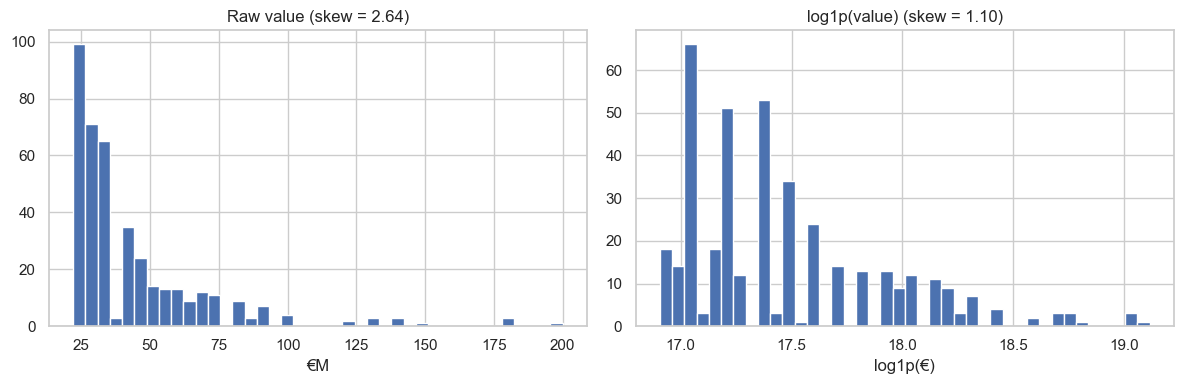

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_raw / 1e6, bins=40)
axes[0].set(title=f'Raw value (skew = {y_raw.skew():.2f})', xlabel='€M')
axes[1].hist(y_log, bins=40)
axes[1].set(title=f'log1p(value) (skew = {y_log.skew():.2f})', xlabel='log1p(€)')
plt.tight_layout()

## 2. One leakage-safe pipeline per model

Scaling and one-hot encoding live *inside* the pipeline, and the grid search tunes the
**whole pipeline** — so in every CV fold the scaler is fit on that fold's training part
only. Preprocessing never sees validation rows: no leakage by construction.

The tuning discipline: hyperparameters are selected with 5-fold CV **on the training
split only**. The 20% test set stays untouched until the final comparison in section 5 —
otherwise we'd be picking whichever hyperparameters flatter those particular players,
and the test metric would stop being an honest estimate of generalization
(*model selection* must not contaminate *model assessment*).

In [3]:
models = build_models()
PARAM_GRIDS

{'Ridge': {'model__alpha': array([1.00000000e-02, 3.16227766e-02, 1.00000000e-01, 3.16227766e-01,
         1.00000000e+00, 3.16227766e+00, 1.00000000e+01, 3.16227766e+01,
         1.00000000e+02, 3.16227766e+02, 1.00000000e+03])},
 'RandomForest': {'model__max_depth': [None, 5, 10],
  'model__min_samples_leaf': [1, 5, 10],
  'model__max_features': ['sqrt', 0.5, 1.0]},
 'GradientBoosting': {'model__learning_rate': [0.01, 0.05, 0.1],
  'model__n_estimators': [100, 300],
  'model__max_depth': [2, 3]}}

## 3. Ridge — the validation curve for alpha

`alpha` is the bias–variance knob: larger values shrink coefficients toward zero
(more bias, less variance). With only 324 training rows and a noisy target, we should
expect the data to ask for substantial shrinkage.

Best alpha: 31.6  (CV R² = 0.191 ± 0.121)


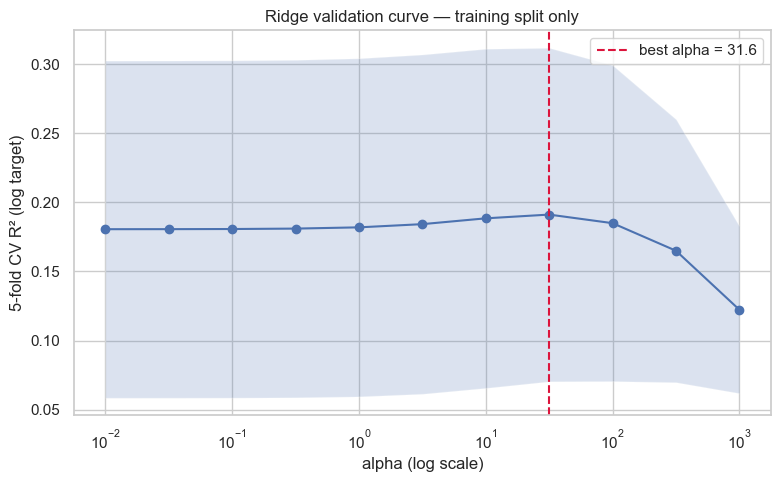

In [4]:
alphas = PARAM_GRIDS['Ridge']['model__alpha']
ridge = models['Ridge']

means, stds = [], []
for a in alphas:
    ridge.set_params(model__alpha=a)
    scores = cross_val_score(ridge, X_train, y_train_log, cv=5, scoring='r2')
    means.append(scores.mean())
    stds.append(scores.std())
means, stds = np.array(means), np.array(stds)

best_alpha = alphas[means.argmax()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(alphas, means, marker='o')
ax.fill_between(alphas, means - stds, means + stds, alpha=0.2)
ax.axvline(best_alpha, color='crimson', ls='--', label=f'best alpha = {best_alpha:.1f}')
ax.set(xscale='log', xlabel='alpha (log scale)', ylabel='5-fold CV R² (log target)',
       title='Ridge validation curve — training split only')
ax.legend()
print(f'Best alpha: {best_alpha:.1f}  (CV R² = {means.max():.3f} ± {stds[means.argmax()]:.3f})')

**Read:** the curve peaks around alpha ≈ 30 — over an order of magnitude more shrinkage
than the scikit-learn default of 1.0. That is the dataset saying that at n = 324,
variance is the dominant error source: the unregularized coefficient estimates are
mostly noise, and shrinking them hard wins. With 10× more data the peak would move left.

## 4. Tree ensembles — grid search

Same discipline for RandomForest and GradientBoosting. The grids explore how much
complexity each ensemble is allowed (depth, leaf size, learning rate).

In [5]:
searches = {}
for name in ['RandomForest', 'GradientBoosting']:
    search = GridSearchCV(models[name], PARAM_GRIDS[name], cv=5, scoring='r2', n_jobs=-1)
    search.fit(X_train, y_train_log)
    searches[name] = search
    print(f'{name}: best CV R² = {search.best_score_:.3f}  params = {search.best_params_}')

top5 = pd.concat({
    name: pd.DataFrame(s.cv_results_)
            .nlargest(5, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
    for name, s in searches.items()
})
top5.round(3)

RandomForest: best CV R² = 0.170  params = {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1}


GradientBoosting: best CV R² = 0.173  params = {'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 300}


params  \
RandomForest     9   {'model__max_depth': 5, 'model__max_features':...   
                 12  {'model__max_depth': 5, 'model__max_features':...   
                 10  {'model__max_depth': 5, 'model__max_features':...   
                 19  {'model__max_depth': 10, 'model__max_features'...   
                 1   {'model__max_depth': None, 'model__max_feature...   
GradientBoosting 1   {'model__learning_rate': 0.01, 'model__max_dep...   
                 4   {'model__learning_rate': 0.05, 'model__max_dep...   
                 0   {'model__learning_rate': 0.01, 'model__max_dep...   
                 3   {'model__learning_rate': 0.01, 'model__max_dep...   
                 8   {'model__learning_rate': 0.1, 'model__max_dept...   

                     mean_test_score  std_test_score  
RandomForest     9             0.170           0.105  
                 12            0.164           0.103  
                 10            0.162           0.104  
                 19            0.160           0.103  
                 1             0.160           0.104  
GradientBoosting 1             0.173           0.102  
                 4             0.165           0.111  
                 0             0.136           0.078  
                 3             0.135           0.117  
                 8             0.131           0.138

**Read:** both ensembles pick their most *conservative* corner of the grid — shallow
trees, decorrelated splits (`max_features='sqrt'`), tiny learning rate. The grid is
telling the same story as the Ridge curve: this problem punishes variance. And even at
their most restrained, the trees are hunting for interactions and thresholds that
cannot be estimated from 324 rows — while Ridge's linear inductive bias happens to
match the (roughly linear, weak) true signal.

## 5. Final comparison on the untouched test set

Each tuned model is refit on the full training split and scored once on the 20% test
set. Predictions are inverted with `expm1` so R² and MAE are in real euros.

In [6]:
ridge_search = GridSearchCV(models['Ridge'], PARAM_GRIDS['Ridge'], cv=5, scoring='r2', n_jobs=-1)
ridge_search.fit(X_train, y_train_log)
searches['Ridge'] = ridge_search

rows = []
for name, search in searches.items():
    pred = np.expm1(search.best_estimator_.predict(X_test))
    rows.append({
        'model': name,
        'cv_r2_log_train': search.best_score_,
        'test_r2_eur': r2_score(y_test_raw, pred),
        'test_mae_eur': mean_absolute_error(y_test_raw, pred),
        'best_params': {k.removeprefix('model__'): v for k, v in search.best_params_.items()},
    })
leaderboard = pd.DataFrame(rows).sort_values('test_r2_eur', ascending=False).reset_index(drop=True)
leaderboard.round(3)

,model,cv_r2_log_train,test_r2_eur,test_mae_eur,best_params
0,Ridge,0.191,0.249,1.479836e+07,{'alpha': 31.622776601683793}
1,RandomForest,0.170,0.082,1.508305e+07,"{'max_depth': 5, 'max_features': 'sqrt', 'min_..."
2,GradientBoosting,0.173,0.043,1.542803e+07,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est..."


## 6. Honest rankings — out-of-fold predictions

For the "undervalued players" and league-premium analyses we want a prediction for
*every* player, but predicting the training rows with the fitted model would be
in-sample flattery. `cross_val_predict` solves this: each player is predicted by a
fold model that never saw them in training.

Two things to keep in mind when reading the results:
1. The OOF table is an **evaluation device** — the 405 predictions come from 5
   different fold models, not the single final model you would deploy.
2. With alpha ≈ 30 the predictions are pulled hard toward the grand mean. Values are
   right-skewed even in log space, so the *median* player sits below the mean — pulling
   everyone toward the mean lands the median prediction slightly *above* actual value.
   That makes every league's median premium negative; the defensible claim is the
   **ordering across leagues**, not the absolute premium levels.

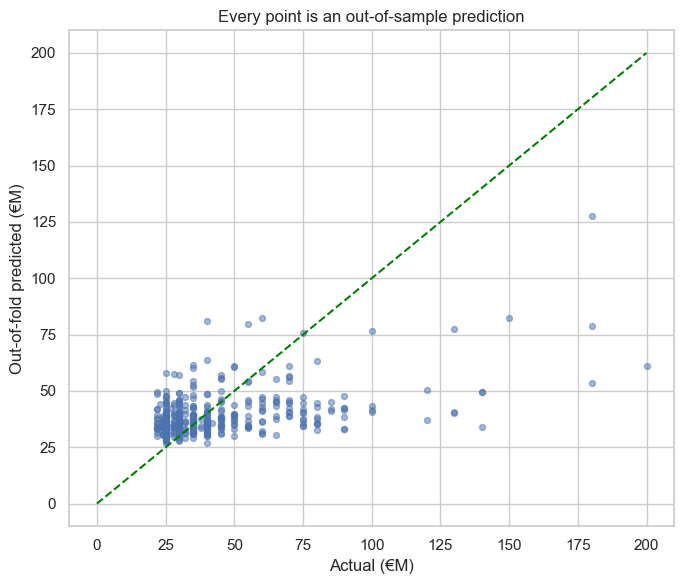

In [7]:
best_pipe = searches['Ridge'].best_estimator_
oof_log = cross_val_predict(clone(best_pipe), X, y_log, cv=5)

scored = df.copy()
scored['predicted_value'] = np.expm1(oof_log)
scored['difference'] = scored['predicted_value'] - scored[TARGET]
scored['premium_pct'] = (scored[TARGET] / scored['predicted_value'] - 1) * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(scored[TARGET] / 1e6, scored['predicted_value'] / 1e6, alpha=0.5, s=18)
lim = max(scored[TARGET].max(), scored['predicted_value'].max()) / 1e6
ax.plot([0, lim], [0, lim], ls='--', color='green')
ax.set(xlabel='Actual (€M)', ylabel='Out-of-fold predicted (€M)',
       title='Every point is an out-of-sample prediction')
plt.tight_layout()

In [8]:
league_premium = (
    scored.groupby('league')
    .agg(n=('player_name', 'size'),
         median_value=(TARGET, 'median'),
         median_predicted=('predicted_value', 'median'),
         median_premium_pct=('premium_pct', 'median'))
    .sort_values('median_premium_pct', ascending=False)
)
display(league_premium.round(2))

scored.nlargest(10, 'difference')[
    ['player_name', 'league', 'value_eur', 'predicted_value', 'difference']
].round(0)

,n,median_value,median_predicted,median_premium_pct
league,,,,
es La Liga,56,40000000.0,40528594.22,-0.99
eng Premier League,206,35000000.0,37396467.73,-2.58
de Bundesliga,46,30000000.0,35100903.11,-8.22
it Serie A,68,30000000.0,34248538.38,-11.22
fr Ligue 1,29,35000000.0,39795529.80,-16.05


,player_name,league,value_eur,predicted_value,difference
141,Mason Greenwood,fr Ligue 1,40000000.0,81192163.0,41192163.0
263,Alberto Moleiro,es La Liga,25000000.0,58055962.0,33055962.0
140,Jack Grealish,eng Premier League,28000000.0,57557425.0,29557425.0
319,Rômulo,de Bundesliga,22000000.0,49738706.0,27738706.0
12,Antony,es La Liga,30000000.0,56992903.0,26992903.0
260,Yankuba Minteh,eng Premier League,35000000.0,61734527.0,26734527.0
0,Matthis Abline,fr Ligue 1,22000000.0,48540544.0,26540544.0
244,Jean-Philippe Mateta,eng Premier League,35000000.0,60339130.0,25339130.0
84,Kiernan Dewsbury-Hall,eng Premier League,25000000.0,50104429.0,25104429.0
97,Jeremy Doku,eng Premier League,55000000.0,79552079.0,24552079.0


## Conclusions — what got productionized

1. **Ridge with alpha ≈ 31.6**, selected by 5-fold CV on the training split
   (`GridSearchCV` in `src/model.py`).
2. **Tuned tree ensembles still lose** — and they lose *while choosing their most
   conservative hyperparameters*, which is the bias–variance story made empirical.
3. **All rankings are out-of-fold** — no player is scored by a model that trained
   on them, in `src/model.py` and the Streamlit dashboard alike.
4. Every number above is reproducible: `python src/model.py` prints the same
   leaderboard, and CI re-validates the dataset (Great Expectations) and the cleaning
   utilities (pytest) on every push.